In [1]:
%pip install matplotlib seaborn pillow pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [18]:
"""
ImageNet Dataset Cleaning and Analysis Pipeline
This notebook analyzes metadata from Visual Layer and creates a cleaned dataset
without modifying the original local ImageNet files.
"""


# Cell 1: Import Libraries and Setup
import json
import os
import shutil
from pathlib import Path
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import pandas as pd
import numpy as np
from datetime import datetime

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [5]:
# ============================================================================
# Cell 2: Configuration and Path Setup
# ============================================================================

# Paths
LOCAL_IMAGENET_BASE = Path("/Users/saeedarellano/Desktop/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC")
METADATA_FILES = [
    Path("/Users/saeedarellano/Desktop/imagenet_jsons/metadata_2.json"),
    Path("/Users/saeedarellano/Desktop/imagenet_jsons/metadata-3.json")
]
OUTPUT_BASE = Path("/Users/saeedarellano/visual_layer/capstone_project_Visual-Layer/clean")
DRY_RUN_OUTPUT = OUTPUT_BASE / "dry_run"
FINAL_OUTPUT = OUTPUT_BASE / "final_cleaned_dataset"

print("Configuration loaded successfully!")
print(f"Local ImageNet base: {LOCAL_IMAGENET_BASE}")
print(f"Output directory: {OUTPUT_BASE}")


Configuration loaded successfully!
Local ImageNet base: /Users/saeedarellano/Desktop/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC
Output directory: /Users/saeedarellano/visual_layer/capstone_project_Visual-Layer/clean


In [6]:
# ============================================================================
# Cell 3: Load and Parse Metadata Files
# ============================================================================

def load_metadata(metadata_path):
    """Load metadata JSON file"""
    with open(metadata_path, 'r') as f:
        return json.load(f)

def extract_user_tags(media_item):
    """Extract user tags from media item"""
    tags = []
    for metadata in media_item.get('metadata_items', []):
        if metadata.get('type') == 'user_tag':
            tags.append(metadata['properties']['tag_name'])
    return tags

def extract_issues(media_item):
    """Extract all issues from media item"""
    issues = []
    for metadata in media_item.get('metadata_items', []):
        if metadata.get('type') == 'issue':
            issues.append({
                'issue_type': metadata['properties']['issue_type'],
                'confidence': metadata['properties'].get('confidence', 0)
            })
    return issues

# Load both metadata files
print("Loading metadata files...")
metadata_2 = load_metadata(METADATA_FILES[0])
metadata_3 = load_metadata(METADATA_FILES[1])

print(f"\nMetadata 2: {metadata_2['info']['total_media_items']} items")
print(f"Metadata 3: {metadata_3['info']['total_media_items']} items")

# Combine all media items
all_media_items = metadata_2['media_items'] + metadata_3['media_items']
print(f"Total media items: {len(all_media_items)}")

Loading metadata files...

Metadata 2: 214 items
Metadata 3: 23 items
Total media items: 237


In [7]:
#============================================================================
# Cell 4: Analyze Local Dataset
# ============================================================================

def scan_local_dataset(base_path, splits=['train', 'val', 'test']):
    """Scan local ImageNet dataset and return file inventory"""
    local_files = {}
    
    for split in splits:
        split_path = base_path / split
        if not split_path.exists():
            print(f"Warning: {split} directory not found")
            continue
        
        local_files[split] = []
        for class_dir in split_path.iterdir():
            if class_dir.is_dir():
                for img_file in class_dir.glob('*.JPEG'):
                    local_files[split].append({
                        'filename': img_file.name,
                        'class_id': class_dir.name,
                        'full_path': img_file
                    })
    
    return local_files

print("Scanning local dataset...")
local_inventory = scan_local_dataset(LOCAL_IMAGENET_BASE)

for split, files in local_inventory.items():
    print(f"{split}: {len(files)} images")

Scanning local dataset...
train: 655570 images
val: 0 images
test: 0 images


In [8]:
def match_files(media_items, local_inventory):
    """Match metadata filenames with local dataset files"""
    matches = {'metadata_2': [], 'metadata_3': [], 'unmatched': []}
    
    # Create lookup dictionary for local files
    local_lookup = {}
    for split, files in local_inventory.items():
        for file_info in files:
            local_lookup[file_info['filename']] = file_info
    
    # Match each media item
    for item in media_items:
        filename = item['file_name']
        source = 'metadata_2' if item in metadata_2['media_items'] else 'metadata_3'
        
        if filename in local_lookup:
            matches[source].append({
                'media_item': item,
                'local_file': local_lookup[filename],
                'filename': filename
            })
        else:
            matches['unmatched'].append({
                'media_item': item,
                'filename': filename,
                'source': source
            })
    
    return matches

print("Matching metadata with local files...")
file_matches = match_files(all_media_items, local_inventory)

print(f"\nMatches from metadata_2: {len(file_matches['metadata_2'])}")
print(f"Matches from metadata_3: {len(file_matches['metadata_3'])}")
print(f"Unmatched items: {len(file_matches['unmatched'])}")

Matching metadata with local files...

Matches from metadata_2: 47
Matches from metadata_3: 7
Unmatched items: 183


In [9]:
# ============================================================================
# Cell 6: Extract User Tags by Category
# ============================================================================

# Define user tag categories we're looking for
TARGET_TAGS = [
    'Mislabel_duplicate',
    'Mislabel_noprimary',
    'train_leakage',
    'Mislabel_nondominant',
    'Mislabel_wrong',
    'Train_leakage'
]

tagged_images = defaultdict(list)

for item in all_media_items:
    tags = extract_user_tags(item)
    for tag in tags:
        # Check for target tags (case-insensitive)
        for target_tag in TARGET_TAGS:
            if target_tag.lower() in tag.lower():
                tagged_images[target_tag].append(item)

print("\nUser Tag Summary:")
for tag, items in tagged_images.items():
    print(f"{tag}: {len(items)} images")


User Tag Summary:
Mislabel_noprimary: 11 images
Mislabel_nondominant: 30 images
Mislabel_wrong: 5 images



Generating example images for each user tag...

Examples for: Mislabel_noprimary


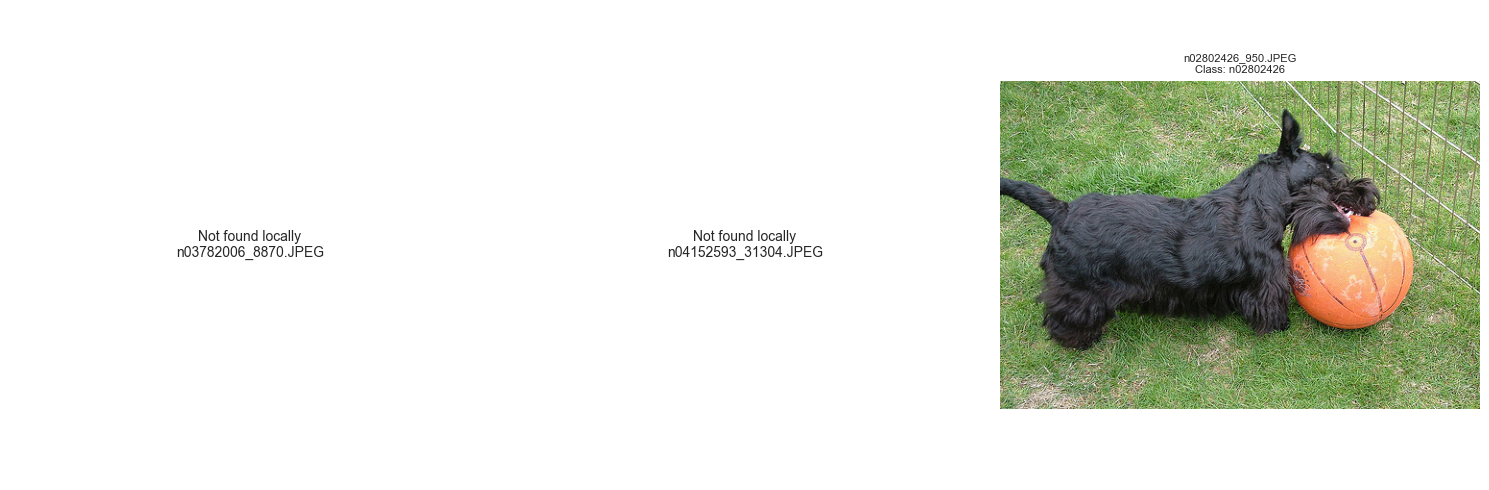


Showing 3 examples out of 11 total

  Example 1: n03782006_8870.JPEG
    Issues: ['outliers', 'mislabels', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates']

  Example 2: n04152593_31304.JPEG
    Issues: ['mislabels', 'outliers', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates']

  Example 3: n02802426_950.JPEG
    Issues: ['mislabels', 'outliers', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'label outlier']

Examples for: Mislabel_nondominant


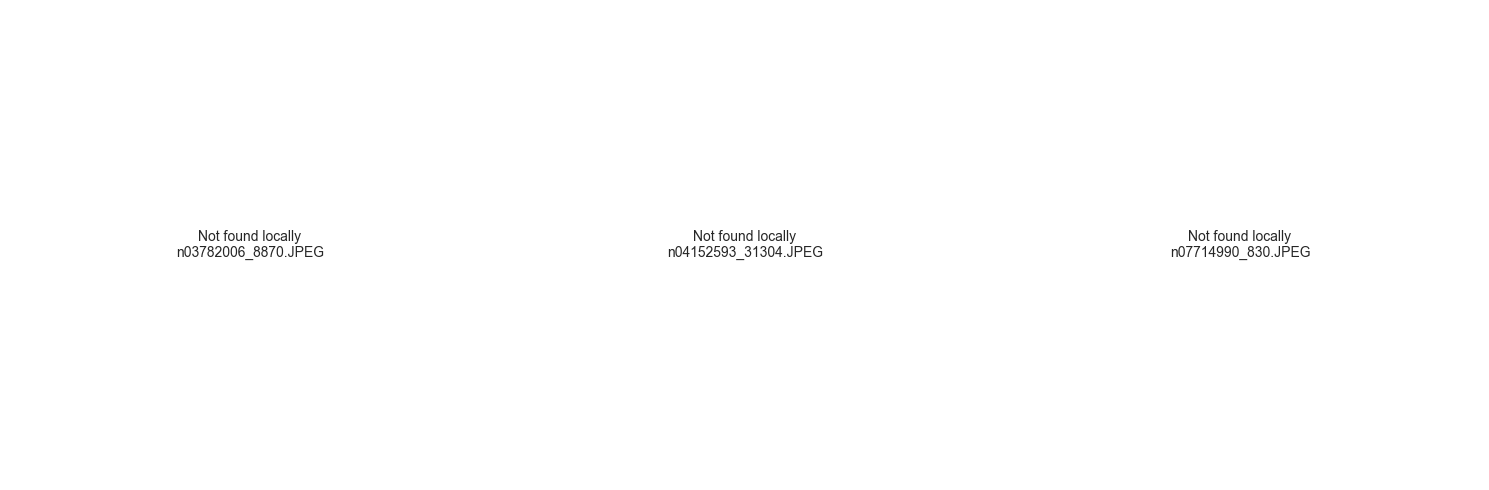


Showing 3 examples out of 30 total

  Example 1: n03782006_8870.JPEG
    Issues: ['outliers', 'mislabels', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates']

  Example 2: n04152593_31304.JPEG
    Issues: ['mislabels', 'outliers', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates']

  Example 3: n07714990_830.JPEG
    Issues: ['mislabels', 'outliers', 'duplicates']

Examples for: Mislabel_wrong


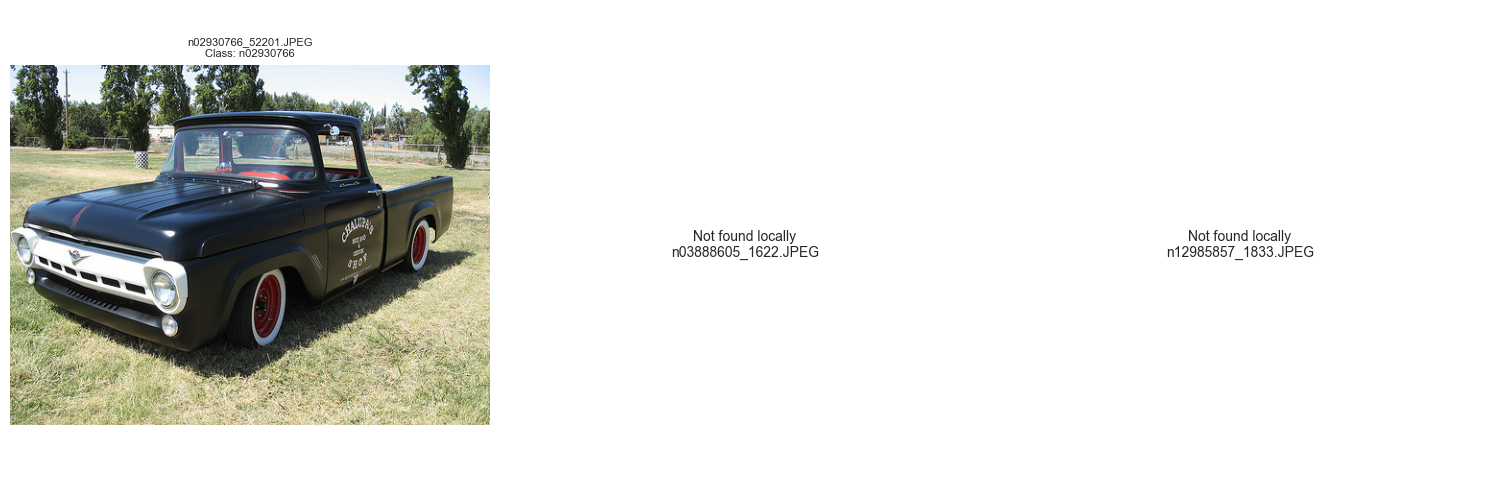


Showing 3 examples out of 5 total

  Example 1: n02930766_52201.JPEG
    Issues: ['mislabels', 'outliers', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates']

  Example 2: n03888605_1622.JPEG
    Issues: ['mislabels', 'outliers', 'duplicates', 'duplicates', 'duplicates', 'label outlier']

  Example 3: n12985857_1833.JPEG
    Issues: ['mislabels', 'outliers', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates', 'duplicates']


In [10]:
# ============================================================================
# Cell 7: Display Example Images for Each User Tag - redo this 
# ============================================================================

def display_example_images(tagged_images, local_inventory, num_examples=3):
    """Display example images for each user tag category"""
    
    # Create local lookup
    local_lookup = {}
    for split, files in local_inventory.items():
        for file_info in files:
            local_lookup[file_info['filename']] = file_info
    
    for tag, items in tagged_images.items():
        if not items:
            continue
        
        print(f"\n{'='*60}")
        print(f"Examples for: {tag}")
        print(f"{'='*60}")
        
        num_to_show = min(num_examples, len(items))
        fig, axes = plt.subplots(1, num_to_show, figsize=(5*num_to_show, 5))
        if num_to_show == 1:
            axes = [axes]
        
        for idx, item in enumerate(items[:num_to_show]):
            filename = item['file_name']
            
            # Try to load image from local dataset
            if filename in local_lookup:
                img_path = local_lookup[filename]['full_path']
                try:
                    img = Image.open(img_path)
                    axes[idx].imshow(img)
                    axes[idx].set_title(f"{filename}\nClass: {local_lookup[filename]['class_id']}", 
                                       fontsize=8)
                    axes[idx].axis('off')
                except Exception as e:
                    axes[idx].text(0.5, 0.5, f"Error loading\n{filename}", 
                                  ha='center', va='center')
                    axes[idx].axis('off')
            else:
                axes[idx].text(0.5, 0.5, f"Not found locally\n{filename}", 
                              ha='center', va='center')
                axes[idx].axis('off')
        
        plt.tight_layout()
        plt.savefig(OUTPUT_BASE / f"examples_{tag}.png", dpi=150, bbox_inches='tight')
        plt.show()
        
        # Print metadata info
        print(f"\nShowing {num_to_show} examples out of {len(items)} total")
        for i, item in enumerate(items[:num_to_show], 1):
            issues = extract_issues(item)
            print(f"\n  Example {i}: {item['file_name']}")
            print(f"    Issues: {[iss['issue_type'] for iss in issues]}")

# Create output directory
OUTPUT_BASE.mkdir(parents=True, exist_ok=True)

print("\nGenerating example images for each user tag...")
display_example_images(tagged_images, local_inventory, num_examples=3)


Creating comprehensive issue visualizations...


/var/folders/z1/937c5wrj72738mbnnd8s3yn00000gn/T/ipykernel_4237/3142278106.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=issues_df, x='Count', y='Issue Type', palette='viridis', ax=ax1)
/var/folders/z1/937c5wrj72738mbnnd8s3yn00000gn/T/ipykernel_4237/3142278106.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mislabel_df, x='Count', y='Mislabel Type',


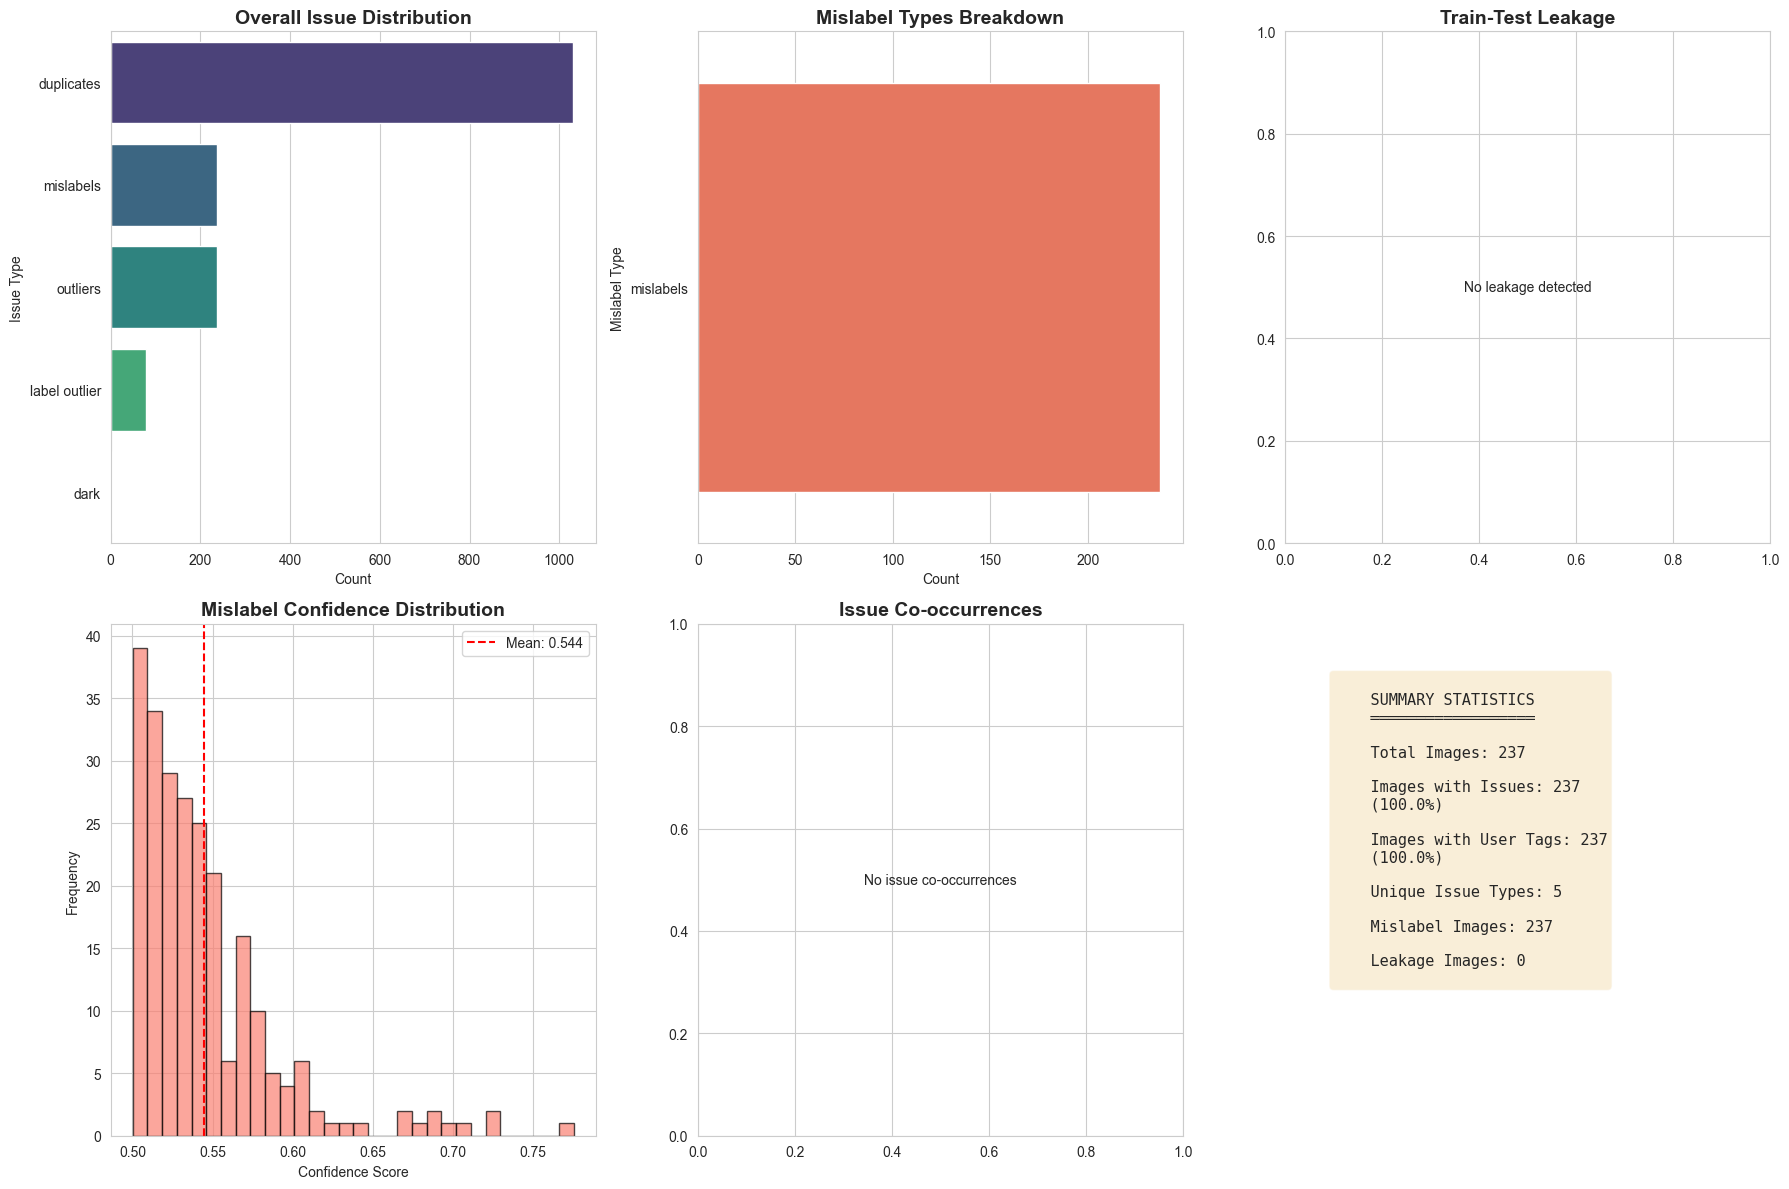

In [11]:
# ============================================================================
# Cell 8: Visualize Leaks and Mislabels - redo this 
# ============================================================================

def create_issue_visualizations(media_items):
    """Create comprehensive visualizations for issues"""
    
    # Collect all issues
    issue_counts = Counter()
    mislabel_types = Counter()
    leak_info = []
    
    for item in media_items:
        issues = extract_issues(item)
        tags = extract_user_tags(item)
        
        for issue in issues:
            issue_type = issue['issue_type']
            issue_counts[issue_type] += 1
            
            if 'mislabel' in issue_type.lower():
                mislabel_types[issue_type] += 1
        
        # Check for leakage tags
        for tag in tags:
            if 'leak' in tag.lower():
                leak_info.append({
                    'filename': item['file_name'],
                    'tag': tag,
                    'confidence': max([i['confidence'] for i in issues], default=0)
                })
    
    # Create figure with multiple subplots
    fig = plt.figure(figsize=(18, 12))
    
    # 1. Overall issue distribution
    ax1 = plt.subplot(2, 3, 1)
    issues_df = pd.DataFrame(list(issue_counts.items()), columns=['Issue Type', 'Count'])
    issues_df = issues_df.sort_values('Count', ascending=False)
    sns.barplot(data=issues_df, x='Count', y='Issue Type', palette='viridis', ax=ax1)
    ax1.set_title('Overall Issue Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Count')
    
    # 2. Mislabel types breakdown
    ax2 = plt.subplot(2, 3, 2)
    if mislabel_types:
        mislabel_df = pd.DataFrame(list(mislabel_types.items()), 
                                   columns=['Mislabel Type', 'Count'])
        sns.barplot(data=mislabel_df, x='Count', y='Mislabel Type', 
                   palette='Reds', ax=ax2)
        ax2.set_title('Mislabel Types Breakdown', fontsize=14, fontweight='bold')
    else:
        ax2.text(0.5, 0.5, 'No mislabels detected', ha='center', va='center')
        ax2.set_title('Mislabel Types Breakdown', fontsize=14, fontweight='bold')
    
    # 3. Leakage analysis
    ax3 = plt.subplot(2, 3, 3)
    if leak_info:
        leak_df = pd.DataFrame(leak_info)
        leak_tag_counts = leak_df['tag'].value_counts()
        leak_tag_counts.plot(kind='bar', color='coral', ax=ax3)
        ax3.set_title(f'Train-Test Leakage ({len(leak_info)} images)', 
                     fontsize=14, fontweight='bold')
        ax3.set_xlabel('Tag Type')
        ax3.set_ylabel('Count')
        ax3.tick_params(axis='x', rotation=45)
    else:
        ax3.text(0.5, 0.5, 'No leakage detected', ha='center', va='center')
        ax3.set_title('Train-Test Leakage', fontsize=14, fontweight='bold')
    
    # 4. Confidence distribution for mislabels
    ax4 = plt.subplot(2, 3, 4)
    mislabel_confidences = []
    for item in media_items:
        issues = extract_issues(item)
        for issue in issues:
            if 'mislabel' in issue['issue_type'].lower():
                mislabel_confidences.append(issue['confidence'])
    
    if mislabel_confidences:
        ax4.hist(mislabel_confidences, bins=30, color='salmon', edgecolor='black', alpha=0.7)
        ax4.set_title('Mislabel Confidence Distribution', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Confidence Score')
        ax4.set_ylabel('Frequency')
        ax4.axvline(np.mean(mislabel_confidences), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(mislabel_confidences):.3f}')
        ax4.legend()
    else:
        ax4.text(0.5, 0.5, 'No mislabel confidence data', ha='center', va='center')
        ax4.set_title('Mislabel Confidence Distribution', fontsize=14, fontweight='bold')
    
    # 5. Issue co-occurrence
    ax5 = plt.subplot(2, 3, 5)
    issue_combinations = Counter()
    for item in media_items:
        issues = extract_issues(item)
        if len(issues) > 1:
            issue_types = tuple(sorted([i['issue_type'] for i in issues]))
            if len(issue_types) == 2:  # Only count pairs
                issue_combinations[issue_types] += 1
    
    if issue_combinations:
        top_combos = dict(issue_combinations.most_common(10))
        combo_labels = [f"{a[:15]}...\n+ {b[:15]}..." for a, b in top_combos.keys()]
        ax5.barh(combo_labels, list(top_combos.values()), color='teal')
        ax5.set_title('Top 10 Issue Co-occurrences', fontsize=14, fontweight='bold')
        ax5.set_xlabel('Count')
    else:
        ax5.text(0.5, 0.5, 'No issue co-occurrences', ha='center', va='center')
        ax5.set_title('Issue Co-occurrences', fontsize=14, fontweight='bold')
    
    # 6. Summary statistics
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')
    
    total_items = len(media_items)
    items_with_issues = sum(1 for item in media_items if extract_issues(item))
    items_with_tags = sum(1 for item in media_items if extract_user_tags(item))
    
    summary_text = f"""
    SUMMARY STATISTICS
    ══════════════════
    
    Total Images: {total_items:,}
    
    Images with Issues: {items_with_issues:,}
    ({items_with_issues/total_items*100:.1f}%)
    
    Images with User Tags: {items_with_tags:,}
    ({items_with_tags/total_items*100:.1f}%)
    
    Unique Issue Types: {len(issue_counts)}
    
    Mislabel Images: {sum(mislabel_types.values()):,}
    
    Leakage Images: {len(leak_info):,}
    """
    
    ax6.text(0.1, 0.9, summary_text, transform=ax6.transAxes, 
            fontsize=11, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(OUTPUT_BASE / 'issue_visualizations.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return issue_counts, mislabel_types, leak_info

print("\nCreating comprehensive issue visualizations...")
issue_counts, mislabel_types, leak_info = create_issue_visualizations(all_media_items)



Analyzing mislabel clustering...


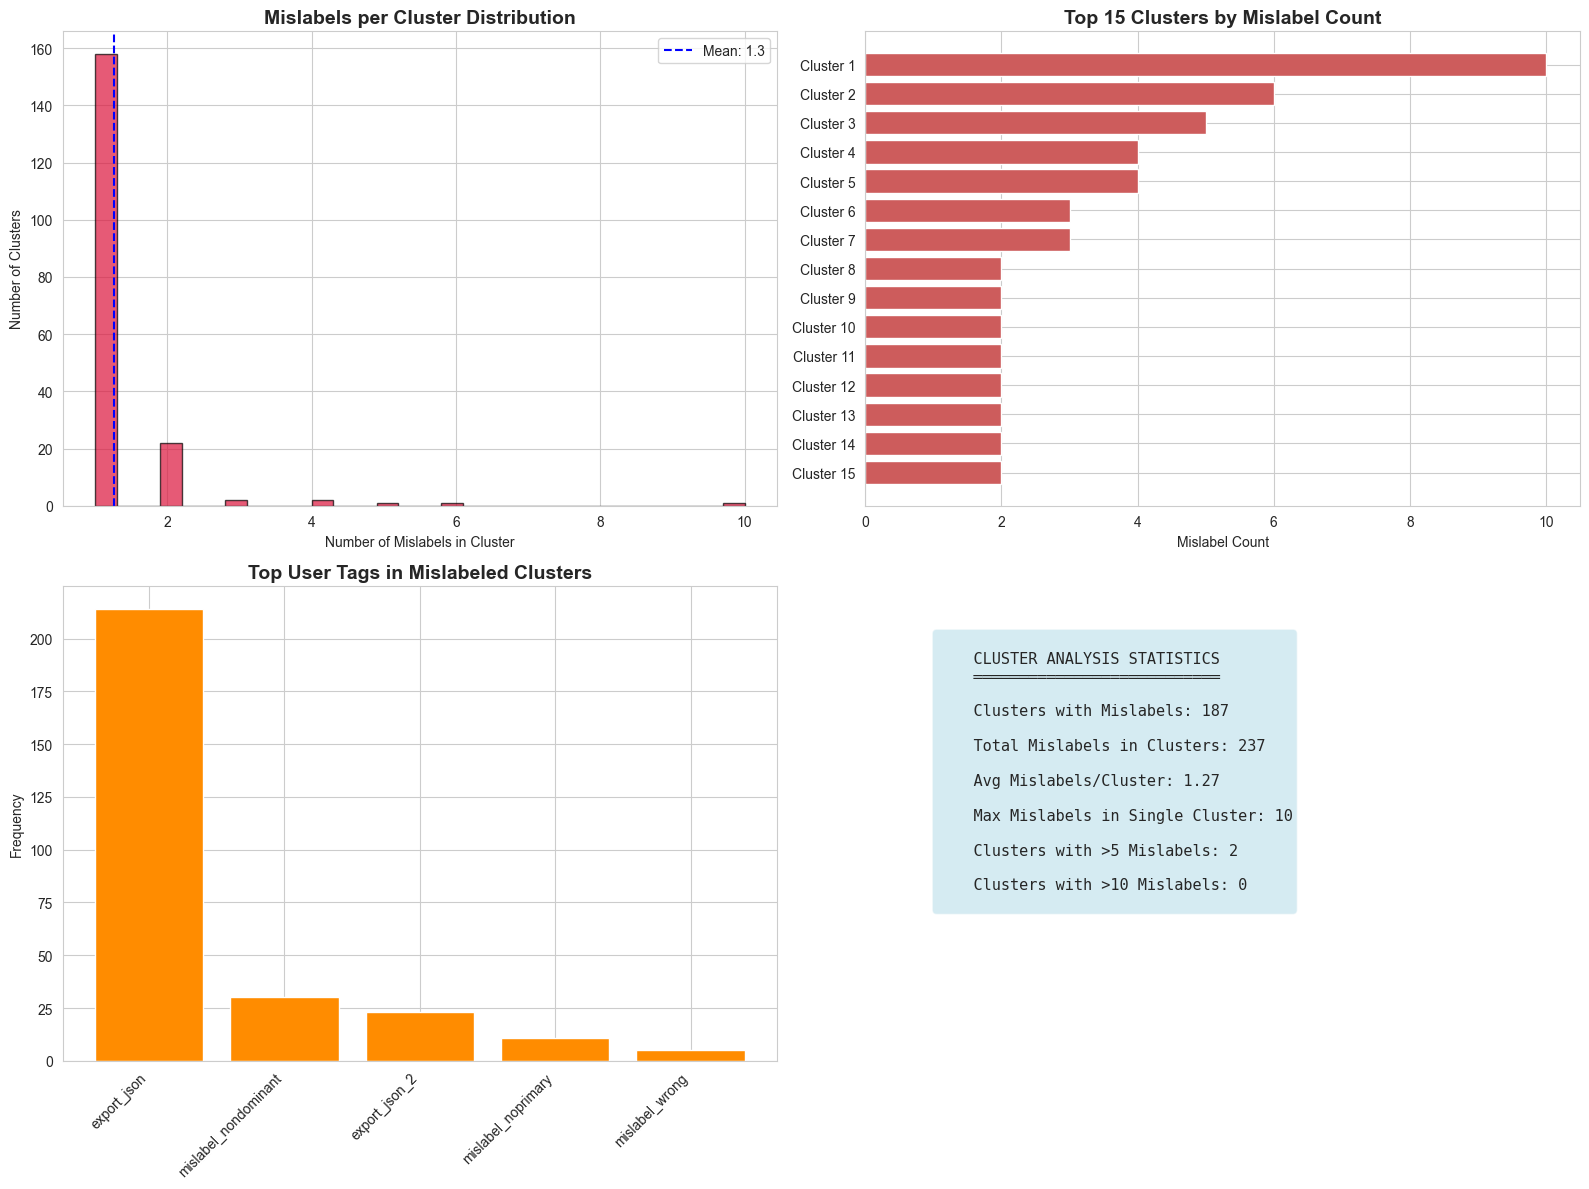

In [12]:
# ============================================================================
# Cell 9: Cluster Analysis for Mislabels - redo this
# ============================================================================

def analyze_mislabel_clusters(media_items):
    """Analyze clustering of mislabeled images"""
    
    # Group images by cluster
    cluster_mislabels = defaultdict(lambda: {'count': 0, 'items': [], 'tags': []})
    
    for item in media_items:
        cluster_id = item.get('cluster_id')
        if not cluster_id:
            continue
        
        issues = extract_issues(item)
        tags = extract_user_tags(item)
        
        has_mislabel = any('mislabel' in i['issue_type'].lower() for i in issues)
        
        if has_mislabel:
            cluster_mislabels[cluster_id]['count'] += 1
            cluster_mislabels[cluster_id]['items'].append(item)
            cluster_mislabels[cluster_id]['tags'].extend(tags)
    
    # Visualize
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Distribution of mislabels per cluster
    ax1 = axes[0, 0]
    cluster_counts = [info['count'] for info in cluster_mislabels.values()]
    ax1.hist(cluster_counts, bins=30, color='crimson', edgecolor='black', alpha=0.7)
    ax1.set_title('Mislabels per Cluster Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of Mislabels in Cluster')
    ax1.set_ylabel('Number of Clusters')
    ax1.axvline(np.mean(cluster_counts), color='blue', linestyle='--', 
               label=f'Mean: {np.mean(cluster_counts):.1f}')
    ax1.legend()
    
    # 2. Top clusters with most mislabels
    ax2 = axes[0, 1]
    top_clusters = sorted(cluster_mislabels.items(), key=lambda x: x[1]['count'], reverse=True)[:15]
    cluster_names = [f"Cluster {i+1}" for i in range(len(top_clusters))]
    cluster_values = [info[1]['count'] for info in top_clusters]
    ax2.barh(cluster_names, cluster_values, color='indianred')
    ax2.set_title('Top 15 Clusters by Mislabel Count', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Mislabel Count')
    ax2.invert_yaxis()
    
    # 3. Tag distribution in mislabeled clusters
    ax3 = axes[1, 0]
    all_cluster_tags = []
    for info in cluster_mislabels.values():
        all_cluster_tags.extend(info['tags'])
    
    if all_cluster_tags:
        tag_counts = Counter(all_cluster_tags)
        top_tags = dict(tag_counts.most_common(10))
        ax3.bar(range(len(top_tags)), list(top_tags.values()), color='darkorange')
        ax3.set_xticks(range(len(top_tags)))
        ax3.set_xticklabels([t[:20] for t in top_tags.keys()], rotation=45, ha='right')
        ax3.set_title('Top User Tags in Mislabeled Clusters', fontsize=14, fontweight='bold')
        ax3.set_ylabel('Frequency')
    else:
        ax3.text(0.5, 0.5, 'No tags found', ha='center', va='center')
        ax3.set_title('Top User Tags in Mislabeled Clusters', fontsize=14, fontweight='bold')
    
    # 4. Statistics summary
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    total_clusters_with_mislabels = len(cluster_mislabels)
    total_mislabels_in_clusters = sum(info['count'] for info in cluster_mislabels.values())
    avg_mislabels_per_cluster = np.mean(cluster_counts) if cluster_counts else 0
    max_mislabels_in_cluster = max(cluster_counts) if cluster_counts else 0
    
    stats_text = f"""
    CLUSTER ANALYSIS STATISTICS
    ═══════════════════════════
    
    Clusters with Mislabels: {total_clusters_with_mislabels:,}
    
    Total Mislabels in Clusters: {total_mislabels_in_clusters:,}
    
    Avg Mislabels/Cluster: {avg_mislabels_per_cluster:.2f}
    
    Max Mislabels in Single Cluster: {max_mislabels_in_cluster}
    
    Clusters with >5 Mislabels: {sum(1 for c in cluster_counts if c > 5)}
    
    Clusters with >10 Mislabels: {sum(1 for c in cluster_counts if c > 10)}
    """
    
    ax4.text(0.1, 0.9, stats_text, transform=ax4.transAxes,
            fontsize=11, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(OUTPUT_BASE / 'cluster_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return cluster_mislabels

print("\nAnalyzing mislabel clustering...")
cluster_analysis = analyze_mislabel_clusters(all_media_items)


Generating comprehensive statistics...


/var/folders/z1/937c5wrj72738mbnnd8s3yn00000gn/T/ipykernel_4237/709575691.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=source_data, x='Source', y='Matches', palette=['#3498db', '#9b59b6'], ax=ax2)
/var/folders/z1/937c5wrj72738mbnnd8s3yn00000gn/T/ipykernel_4237/709575691.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=issue_df, y='Issue', x='Count', palette='rocket', ax=ax3)


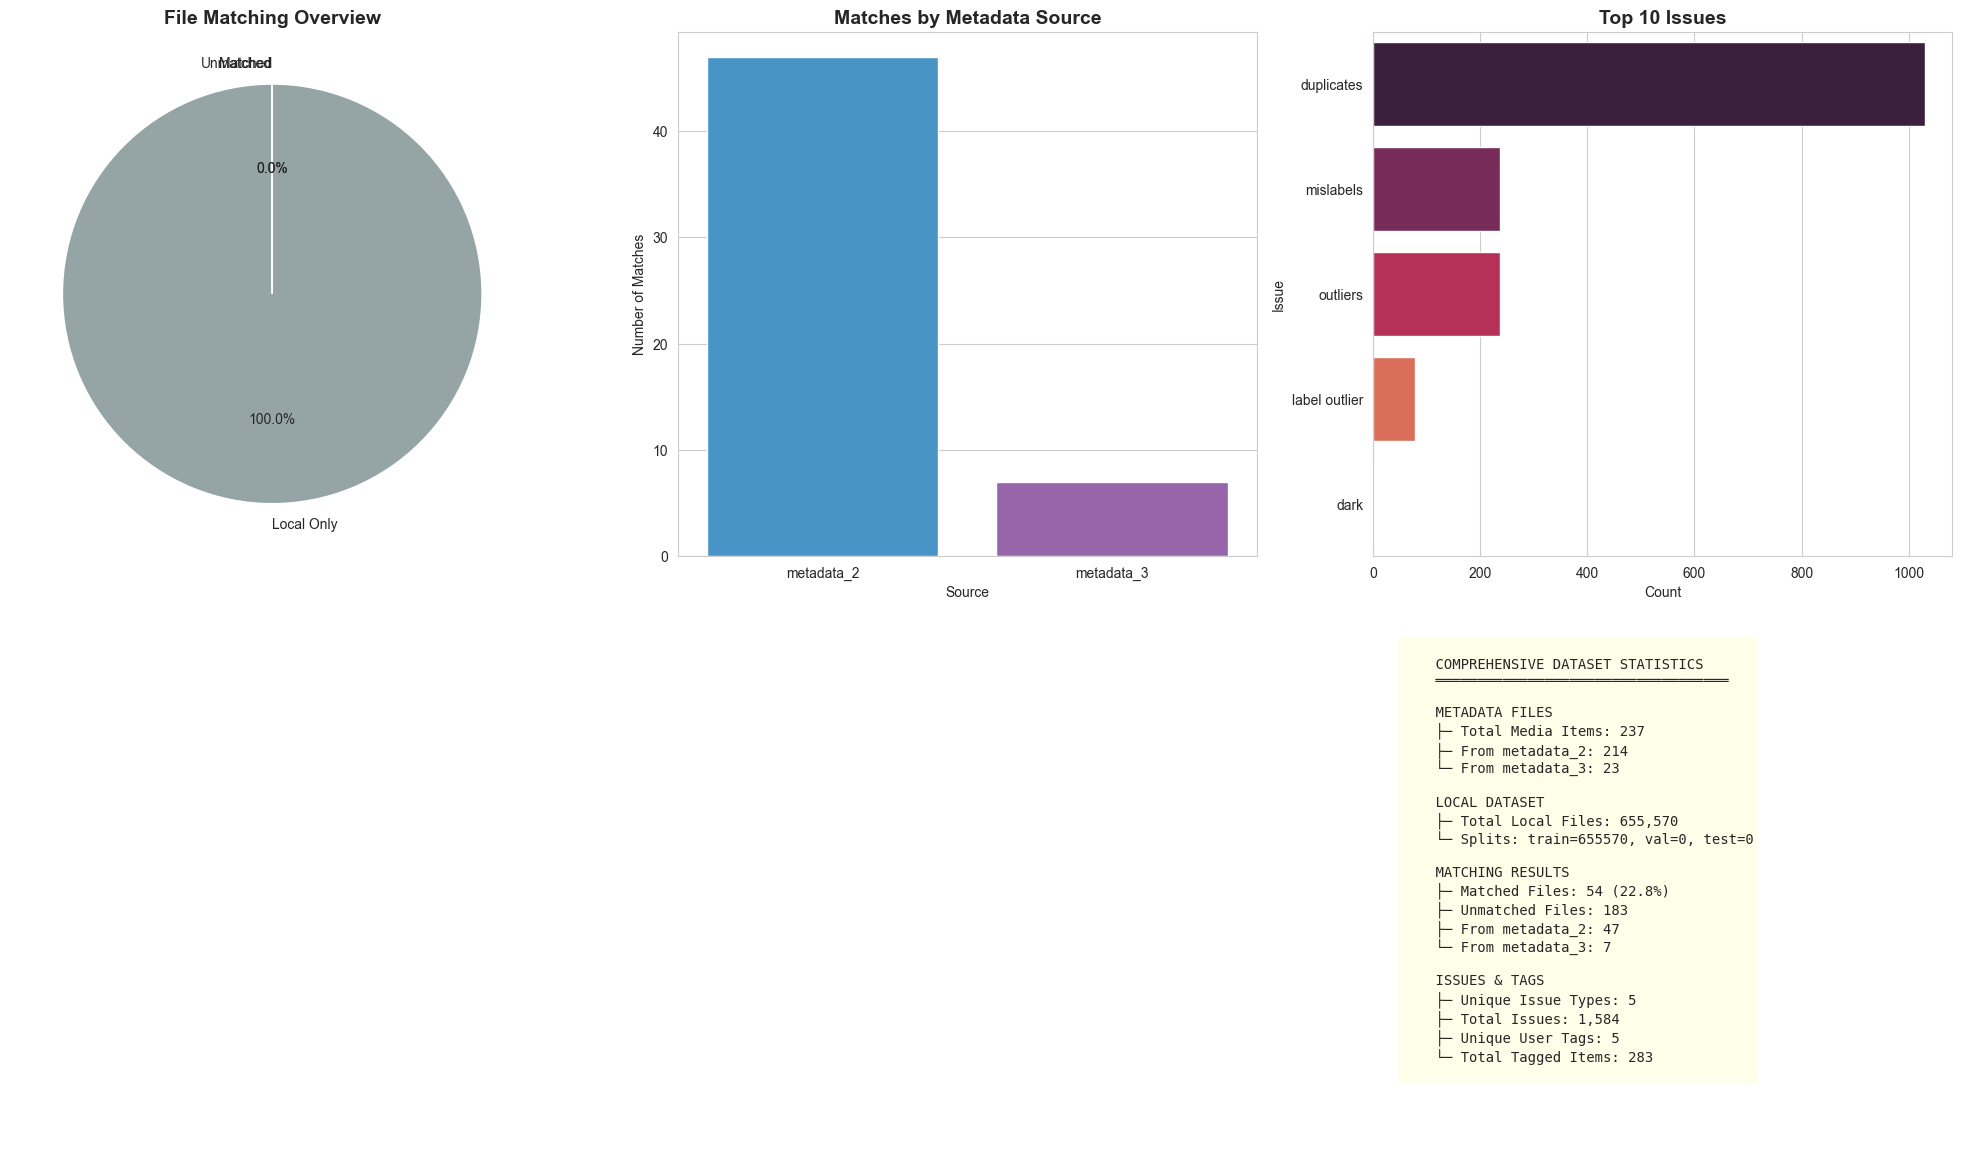

In [16]:
# ============================================================================
# Cell 10: Comprehensive Data Statistics
# ============================================================================

def generate_comprehensive_stats(media_items, file_matches, local_inventory):
    """Generate comprehensive statistics about the dataset"""
    
    # Create detailed statistics
    stats = {
        'total_media_items': len(media_items),
        'matched_files': len(file_matches['metadata_2']) + len(file_matches['metadata_3']),
        'unmatched_files': len(file_matches['unmatched']),
        'metadata_2_matches': len(file_matches['metadata_2']),
        'metadata_3_matches': len(file_matches['metadata_3']),
    }
    
    # Count local files
    total_local = sum(len(files) for files in local_inventory.values())
    stats['total_local_files'] = total_local
    stats['match_percentage'] = (stats['matched_files'] / stats['total_media_items']) * 100
    
    # Issue statistics
    issue_stats = defaultdict(int)
    for item in media_items:
        issues = extract_issues(item)
        for issue in issues:
            issue_stats[issue['issue_type']] += 1
    
    # User tag statistics
    tag_stats = defaultdict(int)
    for item in media_items:
        tags = extract_user_tags(item)
        for tag in tags:
            tag_stats[tag] += 1
    
    # Create visualization
    fig = plt.figure(figsize=(20, 12))
    
    # 1. File matching overview
    ax1 = plt.subplot(2, 3, 1)
    matching_data = pd.DataFrame({
        'Category': ['Matched', 'Unmatched', 'Local Only'],
        'Count': [
            stats['matched_files'],
            stats['unmatched_files'],
            max(0, stats['total_local_files'] - stats['matched_files'])
        ]
    })
    colors = ['#2ecc71', '#e74c3c', '#95a5a6']
    ax1.pie(matching_data['Count'], labels=matching_data['Category'], autopct='%1.1f%%',
           colors=colors, startangle=90)
    ax1.set_title('File Matching Overview', fontsize=14, fontweight='bold')
    
    # 2. Metadata source breakdown
    ax2 = plt.subplot(2, 3, 2)
    source_data = pd.DataFrame({
        'Source': ['metadata_2', 'metadata_3'],
        'Matches': [stats['metadata_2_matches'], stats['metadata_3_matches']]
    })
    sns.barplot(data=source_data, x='Source', y='Matches', palette=['#3498db', '#9b59b6'], ax=ax2)
    ax2.set_title('Matches by Metadata Source', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Number of Matches')
    
    # 3. Top issues
    ax3 = plt.subplot(2, 3, 3)
    top_issues = dict(sorted(issue_stats.items(), key=lambda x: x[1], reverse=True)[:10])
    issue_df = pd.DataFrame(list(top_issues.items()), columns=['Issue', 'Count'])
    sns.barplot(data=issue_df, y='Issue', x='Count', palette='rocket', ax=ax3)
    ax3.set_title('Top 10 Issues', fontsize=14, fontweight='bold')

    
    # 6. Summary table
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')
    
    summary_text = f"""
    COMPREHENSIVE DATASET STATISTICS
    ═══════════════════════════════════
    
    METADATA FILES
    ├─ Total Media Items: {stats['total_media_items']:,}
    ├─ From metadata_2: {len(metadata_2['media_items']):,}
    └─ From metadata_3: {len(metadata_3['media_items']):,}
    
    LOCAL DATASET
    ├─ Total Local Files: {stats['total_local_files']:,}
    └─ Splits: {', '.join(f"{k}={len(v)}" for k, v in local_inventory.items())}
    
    MATCHING RESULTS
    ├─ Matched Files: {stats['matched_files']:,} ({stats['match_percentage']:.1f}%)
    ├─ Unmatched Files: {stats['unmatched_files']:,}
    ├─ From metadata_2: {stats['metadata_2_matches']:,}
    └─ From metadata_3: {stats['metadata_3_matches']:,}
    
    ISSUES & TAGS
    ├─ Unique Issue Types: {len(issue_stats)}
    ├─ Total Issues: {sum(issue_stats.values()):,}
    ├─ Unique User Tags: {len(tag_stats)}
    └─ Total Tagged Items: {sum(tag_stats.values()):,}
    """
    
    ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes,
            fontsize=10, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
    
    plt.tight_layout()
    plt.savefig(OUTPUT_BASE / 'comprehensive_statistics.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return stats, issue_stats, tag_stats

print("\nGenerating comprehensive statistics...")
stats, issue_stats, tag_stats = generate_comprehensive_stats(all_media_items, file_matches, local_inventory)


In [15]:
# ============================================================================
# CELL 7: Analyze What Will Be Removed
# ============================================================================

def analyze_removal_candidates(file_matches):
    """Analyze which files will be excluded and why"""
    
    removal_stats = {
        'total_matched': 0,
        'to_keep': 0,
        'to_remove': 0,
        'removal_reasons': Counter(),
        'removed_by_source': {'metadata_2': 0, 'metadata_3': 0},
        'removed_items': []
    }
    
    for source in ['metadata_2', 'metadata_3']:
        for match in file_matches[source]:
            removal_stats['total_matched'] += 1
            
            should_remove, reason = should_exclude_image(match['media_item'])
            
            if should_remove:
                removal_stats['to_remove'] += 1
                removal_stats['removal_reasons'][reason] += 1
                removal_stats['removed_by_source'][source] += 1
                removal_stats['removed_items'].append({
                    'filename': match['filename'],
                    'reason': reason,
                    'source': source,
                    'class_id': match['local_file']['class_id']
                })
            else:
                removal_stats['to_keep'] += 1
    
    return removal_stats

print("Analyzing removal candidates...")
removal_stats = analyze_removal_candidates(file_matches)

print(f"\nRemoval Analysis:")
print(f"  Total matched files: {removal_stats['total_matched']:,}")
print(f"  Files to KEEP: {removal_stats['to_keep']:,}")
print(f"  Files to REMOVE: {removal_stats['to_remove']:,}")
print(f"\nRemoval reasons:")
for reason, count in removal_stats['removal_reasons'].most_common():
    print(f"  - {reason}: {count:,} files")

print(f"\n✓ Analysis complete!")

Analyzing removal candidates...


NameError: name 'should_exclude_image' is not defined

In [ ]:
# ============================================================================
# CELL 8: DRY RUN - Test Without Modifying Files
# ============================================================================

def perform_dry_run(file_matches, removal_stats, output_dir):
    """Perform a dry run - NO FILES ARE CREATED OR MODIFIED"""
    
    print("\n" + "="*70)
    print("STARTING DRY RUN (No files will be created)")
    print("="*70)
    
    output_dir.mkdir(parents=True, exist_ok=True)
    
    dry_run_report = {
        'timestamp': datetime.now().isoformat(),
        'configuration': {
            'use_symlinks': USE_SYMLINKS,
            'source_dataset': str(LOCAL_IMAGENET_BASE),
            'output_location': str(CLEANED_DATASET_DIR)
        },
        'statistics': {
            'total_files_in_metadata': len(all_media_items),
            'matched_with_local': removal_stats['total_matched'],
            'files_to_keep': removal_stats['to_keep'],
            'files_to_remove': removal_stats['to_remove'],
            'removal_percentage': (removal_stats['to_remove'] / removal_stats['total_matched'] * 100) if removal_stats['total_matched'] > 0 else 0
        },
        'files_by_split': {},
        'removal_reasons': dict(removal_stats['removal_reasons']),
        'sample_kept_files': [],
        'sample_removed_files': removal_stats['removed_items'][:20]
    }
    
    # Count files by split
    for source in ['metadata_2', 'metadata_3']:
        for match in file_matches[source]:
            split = match['local_file']['split']
            should_remove, _ = should_exclude_image(match['media_item'])
            
            if split not in dry_run_report['files_by_split']:
                dry_run_report['files_by_split'][split] = {'keep': 0, 'remove': 0}
            
            if should_remove:
                dry_run_report['files_by_split'][split]['remove'] += 1
            else:
                dry_run_report['files_by_split'][split]['keep'] += 1
                if len(dry_run_report['sample_kept_files']) < 20:
                    dry_run_report['sample_kept_files'].append({
                        'filename': match['filename'],
                        'class_id': match['local_file']['class_id'],
                        'split': split
                    })
    
    print(f"\n📊 DRY RUN SUMMARY")
    print(f"  Total files: {removal_stats['total_matched']:,}")
    print(f"  Will keep: {removal_stats['to_keep']:,} ({removal_stats['to_keep']/removal_stats['total_matched']*100:.1f}%)")
    print(f"  Will remove: {removal_stats['to_remove']:,} ({dry_run_report['statistics']['removal_percentage']:.1f}%)")
    
    print(f"\n📁 Files by split:")
    for split, counts in dry_run_report['files_by_split'].items():
        total = counts['keep'] + counts['remove']
        print(f"  {split}:")
        print(f"    Keep: {counts['keep']:,} / {total:,}")
        print(f"    Remove: {counts['remove']:,} / {total:,}")
    
    report_path = output_dir / 'dry_run_report.json'
    with open(report_path, 'w') as f:
        json.dump(dry_run_report, f, indent=2)
    
    print(f"\n✓ Dry run report saved to: {report_path}")
    print(f"\n⚠️  This was a DRY RUN - no files were created or modified!")
    print(f"   Review the results above before proceeding to the actual cleaning.")
    
    return dry_run_report

# Execute dry run
dry_run_report = perform_dry_run(file_matches, removal_stats, DRY_RUN_DIR)


In [ ]:
def create_cleaned_dataset(file_matches, output_dir, use_symlinks=True):
    """Create the cleaned dataset - DOES NOT MODIFY ORIGINAL DATASET!"""
    
    print("\n" + "="*70)
    print("CREATING CLEANED DATASET")
    print("="*70)
    print(f"Method: {'SYMLINKS' if use_symlinks else 'COPYING FILES'}")
    print(f"Output: {output_dir}")
    print("\n⚠️  YOUR ORIGINAL DATASET WILL NOT BE MODIFIED!\n")
    
    output_dir.mkdir(parents=True, exist_ok=True)
    
    cleaning_log = {
        'timestamp': datetime.now().isoformat(),
        'method': 'symlinks' if use_symlinks else 'copy',
        'files_processed': 0,
        'files_kept': 0,
        'files_excluded': 0,
        'errors': [],
        'manifest': []
    }
    
    for source in ['metadata_2', 'metadata_3']:
        for match in file_matches[source]:
            cleaning_log['files_processed'] += 1
            
            should_remove, reason = should_exclude_image(match['media_item'])
            
            if should_remove:
                cleaning_log['files_excluded'] += 1
                continue
            
            local_file = match['local_file']
            source_path = local_file['full_path']
            
            split = local_file['split']
            class_id = local_file['class_id']
            dest_dir = output_dir / split / class_id
            dest_dir.mkdir(parents=True, exist_ok=True)
            
            dest_path = dest_dir / local_file['filename']
            
            try:
                if use_symlinks:
                    if not dest_path.exists():
                        os.symlink(source_path, dest_path)
                else:
                    if not dest_path.exists():
                        shutil.copy2(source_path, dest_path)
                
                cleaning_log['files_kept'] += 1
                cleaning_log['manifest'].append({
                    'filename': local_file['filename'],
                    'class_id': class_id,
                    'split': split,
                    'source_path': str(source_path),
                    'cleaned_path': str(dest_path)
                })
                
                if cleaning_log['files_kept'] % 1000 == 0:
                    print(f"  Processed {cleaning_log['files_kept']:,} files...")
                    
            except Exception as e:
                cleaning_log['errors'].append({
                    'filename': local_file['filename'],
                    'error': str(e)
                })
    
    log_path = output_dir / 'cleaning_log.json'
    with open(log_path, 'w') as f:
        json.dump(cleaning_log, f, indent=2)
    
    manifest_path = output_dir / 'dataset_manifest.json'
    with open(manifest_path, 'w') as f:
        json.dump({
            'dataset_name': 'ImageNet 1k Cleaned',
            'creation_date': datetime.now().isoformat(),
            'total_files': cleaning_log['files_kept'],
            'method': 'symlinks' if use_symlinks else 'copy',
            'files': cleaning_log['manifest']
        }, f, indent=2)
    
    print(f"\n✓ CLEANING COMPLETE!")
    print(f"  Files processed: {cleaning_log['files_processed']:,}")
    print(f"  Files kept: {cleaning_log['files_kept']:,}")
    print(f"  Files excluded: {cleaning_log['files_excluded']:,}")
    print(f"  Errors: {len(cleaning_log['errors'])}")
    print(f"\n📁 Cleaned dataset location: {output_dir}")
    print(f"📄 Manifest saved to: {manifest_path}")
    
    return cleaning_log

# UNCOMMENT TO RUN ACTUAL CLEANING:
# cleaning_log = create_cleaned_dataset(file_matches, CLEANED_DATASET_DIR, use_symlinks=USE_SYMLINKS)

print("\n⚠️  Cleaning function is defined but NOT executed yet.")
print("   Uncomment the line above to run the actual cleaning.")

In [ ]:
 ============================================================================
# CELL 11: Extract User Tags and Display Examples
# ============================================================================

TARGET_TAGS = [
    'Mislabel_duplicate',
    'Mislabel_noprimary',
    'train_leakage',
    'Mislabel_nondominant',
    'Mislabel_wrong',
    'Train_leakage'
]

tagged_images = defaultdict(list)

for item in all_media_items:
    tags = extract_user_tags(item)
    for tag in tags:
        for target_tag in TARGET_TAGS:
            if target_tag.lower() in tag.lower():
                tagged_images[target_tag].append(item)

print("User Tag Summary:")
for tag, items in tagged_images.items():
    print(f"  {tag}: {len(items)} images")

OUTPUT_BASE.mkdir(parents=True, exist_ok=True)

def display_example_images(tagged_images, local_inventory, num_examples=3):
    local_lookup = {}
    for split, files in local_inventory.items():
        for file_info in files:
            local_lookup[file_info['filename']] = file_info
    
    for tag, items in tagged_images.items():
        if not items:
            continue
        
        print(f"\n{'='*60}")
        print(f"Examples for: {tag}")
        print(f"{'='*60}")
        
        num_to_show = min(num_examples, len(items))
        fig, axes = plt.subplots(1, num_to_show, figsize=(5*num_to_show, 5))
        if num_to_show == 1:
            axes = [axes]
        
        for idx, item in enumerate(items[:num_to_show]):
            filename = item['file_name']
            if filename in local_lookup:
                img_path = local_lookup[filename]['full_path']
                try:
                    img = Image.open(img_path)
                    axes[idx].imshow(img)
                    axes[idx].set_title(f"{filename}\nClass: {local_lookup[filename]['class_id']}", fontsize=8)
                    axes[idx].axis('off')
                except:
                    axes[idx].text(0.5, 0.5, f"Error loading\n{filename}", ha='center', va='center')
                    axes[idx].axis('off')
            else:
                axes[idx].text(0.5, 0.5, f"Not found\n{filename}", ha='center', va='center')
                axes[idx].axis('off')
        
        plt.tight_layout()
        plt.savefig(OUTPUT_BASE / f"examples_{tag}.png", dpi=150, bbox_inches='tight')
        plt.show()

display_example_images(tagged_images, local_inventory, num_examples=3)


In [ ]:
# ============================================================================
# CELL 12: Visualizations - Issue Analysis
# ============================================================================

def create_issue_visualizations(media_items):
    issue_counts = Counter()
    mislabel_types = Counter()
    leak_info = []
    
    for item in media_items:
        issues = extract_issues(item)
        tags = extract_user_tags(item)
        
        for issue in issues:
            issue_type = issue['issue_type']
            issue_counts[issue_type] += 1
            if 'mislabel' in issue_type.lower():
                mislabel_types[issue_type] += 1
        
        for tag in tags:
            if 'leak' in tag.lower():
                leak_info.append({
                    'filename': item['file_name'],
                    'tag': tag,
                    'confidence': max([i['confidence'] for i in issues], default=0)
                })
    
    fig = plt.figure(figsize=(18, 12))
    
    # 1. Issue distribution
    ax1 = plt.subplot(2, 3, 1)
    if issue_counts:
        issues_df = pd.DataFrame(list(issue_counts.items()), columns=['Issue', 'Count'])
        issues_df = issues_df.sort_values('Count', ascending=False).head(15)
        sns.barplot(data=issues_df, x='Count', y='Issue', palette='viridis', ax=ax1)
        ax1.set_title('Top 15 Issues', fontsize=14, fontweight='bold')
    
    # 2. Mislabels
    ax2 = plt.subplot(2, 3, 2)
    if mislabel_types:
        mislabel_df = pd.DataFrame(list(mislabel_types.items()), columns=['Type', 'Count'])
        sns.barplot(data=mislabel_df, x='Count', y='Type', palette='Reds', ax=ax2)
        ax2.set_title('Mislabel Types', fontsize=14, fontweight='bold')
    else:
        ax2.text(0.5, 0.5, 'No mislabels', ha='center', va='center')
    
    # 3. Leakage
    ax3 = plt.subplot(2, 3, 3)
    if leak_info:
        leak_df = pd.DataFrame(leak_info)
        leak_counts = leak_df['tag'].value_counts()
        leak_counts.plot(kind='bar', color='coral', ax=ax3)
        ax3.set_title(f'Train-Test Leakage ({len(leak_info)} images)', fontsize=14, fontweight='bold')
        ax3.tick_params(axis='x', rotation=45)
    else:
        ax3.text(0.5, 0.5, 'No leakage', ha='center', va='center')
    
    # 4. Confidence distribution
    ax4 = plt.subplot(2, 3, 4)
    confidences = [i['confidence'] for item in media_items for i in extract_issues(item) if 'mislabel' in i['issue_type'].lower()]
    if confidences:
        ax4.hist(confidences, bins=30, color='salmon', alpha=0.7)
        ax4.set_title('Mislabel Confidence', fontsize=14, fontweight='bold')
        ax4.axvline(np.mean(confidences), color='red', linestyle='--', label=f'Mean: {np.mean(confidences):.3f}')
        ax4.legend()
    
    # 5. Summary
    ax5 = plt.subplot(2, 3, 5)
    ax5.axis('off')
    summary = f"""SUMMARY
Total Images: {len(media_items):,}
Images w/ Issues: {sum(1 for i in media_items if extract_issues(i)):,}
Mislabels: {sum(mislabel_types.values()):,}
Leakage: {len(leak_info):,}
Unique Issues: {len(issue_counts)}"""
    ax5.text(0.1, 0.5, summary, fontsize=12, fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(OUTPUT_BASE / 'issue_visualizations.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return issue_counts, mislabel_types, leak_info

issue_counts, mislabel_types, leak_info = create_issue_visualizations(all_media_items)

In [ ]:
# ============================================================================
# CELL 13: Cluster Analysis
# ============================================================================

def analyze_clusters(media_items):
    cluster_data = defaultdict(lambda: {'count': 0, 'items': [], 'tags': []})
    
    for item in media_items:
        cluster_id = item.get('cluster_id')
        if not cluster_id:
            continue
        
        issues = extract_issues(item)
        tags = extract_user_tags(item)
        has_mislabel = any('mislabel' in i['issue_type'].lower() for i in issues)
        
        if has_mislabel:
            cluster_data[cluster_id]['count'] += 1
            cluster_data[cluster_id]['items'].append(item)
            cluster_data[cluster_id]['tags'].extend(tags)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    cluster_counts = [d['count'] for d in cluster_data.values()]
    
    if cluster_counts:
        # Distribution
        axes[0, 0].hist(cluster_counts, bins=30, color='crimson', alpha=0.7)
        axes[0, 0].set_title('Mislabels per Cluster', fontsize=14, fontweight='bold')
        axes[0, 0].axvline(np.mean(cluster_counts), color='blue', linestyle='--',
                          label=f'Mean: {np.mean(cluster_counts):.1f}')
        axes[0, 0].legend()
        
        # Top clusters
        top = sorted(cluster_data.items(), key=lambda x: x[1]['count'], reverse=True)[:10]
        names

In [17]:
# ============================================================================
# Cell 11: DRY RUN - Test Dataset Creation
# ============================================================================

def dry_run_cleaning(file_matches, output_dir):
    """Perform a dry run to test the cleaning process"""
    
    print("\n" + "="*60)
    print("STARTING DRY RUN")
    print("="*60)
    
    # Create dry run directory structure
    dry_run_dir = output_dir / "dry_run"
    dry_run_dir.mkdir(parents=True, exist_ok=True)
    
    # Create report
    report = {
        'timestamp': datetime.now().isoformat(),
        'total_files_to_copy': 0,
        'files_by_split': defaultdict(int),
        'files_by_source': {'metadata_2': 0, 'metadata_3': 0},
        'sample_files': []
    }
    
    # Count files to be copied
    for source in ['metadata_2', 'metadata_3']:
        for match in file_matches[source]:
            local_file = match['local_file']
            split = LOCAL_IMAGENET_BASE.name
            for s in ['train', 'val', 'test']:
                if f"/{s}/" in str(local_file['full_path']):
                    split = s
                    break